# SkillSync — Model Building & Evaluation

Trains and compares two sentence embedding models for job recommendation:

| Model | Type | Dim | Notes |
|-------|------|-----|-------|
| **BERT** | `bert-base-uncased` (mean pooling) | 768 | Baseline — general purpose |
| **MiniLM** | `all-MiniLM-L6-v2` | 384 | Production model per Technical Report |

Evaluation covers retrieval quality (MRR, Hit@K), semantic coherence, speed, and a qualitative spot-check.  
The winning model's FAISS index is saved to `ml/embeddings/`.

## 0. Setup & Imports

In [1]:
!pip install sentence-transformers faiss-cpu transformers torch --quiet

In [2]:
import json
import time
import warnings
import numpy as np
import pandas as pd
import faiss
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE
from transformers import BertTokenizer, BertModel
from sentence_transformers import SentenceTransformer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

CLEAN_CSV  = Path('jobs_clean.csv')
OUTPUT_DIR = Path('ml/embeddings')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
TOP_K      = 5
DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print('Setup complete.')

Device : cpu
PyTorch: 2.12.0+cpu
Setup complete.


## 1. Load Dataset

In [4]:
df = pd.read_csv('D:\Skill-Sync\ml\datasets\jobs_clean.csv')
print(f'Loaded {len(df)} jobs  |  Columns: {df.columns.tolist()}')
df.head(3)

Loaded 405 jobs  |  Columns: ['Job_ID', 'Job_Role', 'Skills', 'Skills_Normalised', 'Skills_List', 'Projects', 'Companies', 'Domain', 'Target_Students', 'Experience_Label', 'Experience_Level', 'Salary_Range', 'Salary_Min', 'Salary_Max', 'Salary_Avg', 'Has_Salary_Data', 'Skill_Count', 'Skill_Count_Outlier', 'Embedding_Text']


,Job_ID,Job_Role,Skills,Skills_Normalised,Skills_List,Projects,Companies,Domain,Target_Students,Experience_Label,Experience_Level,Salary_Range,Salary_Min,Salary_Max,Salary_Avg,Has_Salary_Data,Skill_Count,Skill_Count_Outlier,Embedding_Text
0,1,Full Stack Developer,"JavaScript, Python, React, Node.js, MongoDB, A...",javascript | python | react | node.js | mongod...,"[""javascript"", ""python"", ""react"", ""node.js"", ""...","E-commerce Platform, Social Media Dashboard","Google, Facebook, Amazon",Technical,College,Mid-level (2-5 years),2.0,"$90,000 - $140,000",90000,140000,115000,True,12,True,Job Role: Full Stack Developer. Skills: JavaSc...
1,2,Financial Analyst,"Financial Modeling, Excel, Bloomberg Terminal,...",financial modeling | excel | bloomberg termina...,"[""financial modeling"", ""excel"", ""bloomberg ter...","Investment Portfolio Analysis, Market Research...","Goldman Sachs, JP Morgan, Morgan Stanley",General,College,Entry-level (0-2 years),1.0,"$75,000 - $95,000",75000,95000,85000,True,4,False,Job Role: Financial Analyst. Skills: Financial...
2,3,Mechanical Engineer,"AutoCAD, SolidWorks, FEA, GD&T, CAD, Thermodyn...",autocad | solidworks | finite element analysis...,"[""autocad"", ""solidworks"", ""finite element anal...","Product Design, Manufacturing Process Optimiza...","Boeing, General Electric, Siemens",Technical,College,Mid-level (2-5 years),2.0,"$85,000 - $120,000",85000,120000,102500,True,13,True,Job Role: Mechanical Engineer. Skills: AutoCAD...


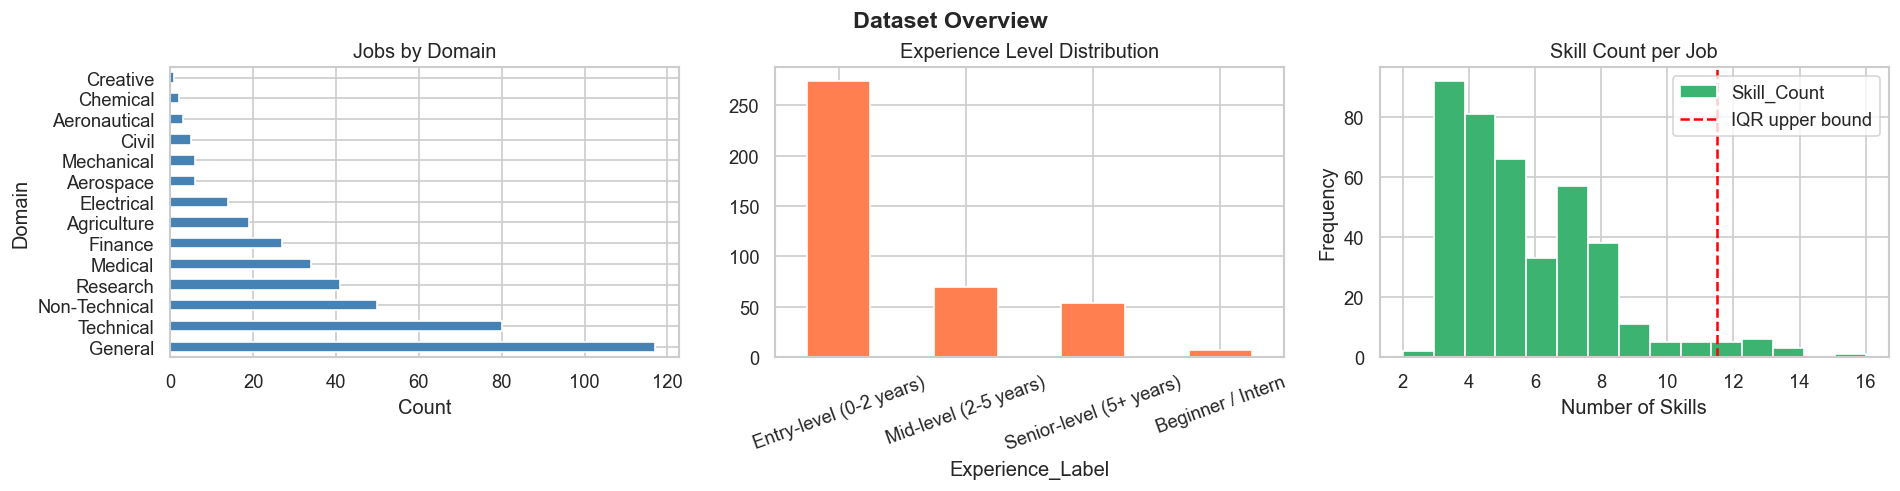

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['Domain'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Jobs by Domain'); axes[0].set_xlabel('Count')

df['Experience_Label'].value_counts().plot(kind='bar', ax=axes[1], color='coral', rot=20)
axes[1].set_title('Experience Level Distribution')

df['Skill_Count'].plot(kind='hist', bins=15, ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Skill Count per Job'); axes[2].set_xlabel('Number of Skills')
q75, q25 = df['Skill_Count'].quantile(0.75), df['Skill_Count'].quantile(0.25)
axes[2].axvline(q75 + 1.5*(q75-q25), color='red', linestyle='--', label='IQR upper bound')
axes[2].legend()

plt.tight_layout()
plt.suptitle('Dataset Overview', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 2. Model A — BERT (`bert-base-uncased`)

Vanilla BERT does not produce sentence embeddings out of the box.  
We use **mean pooling** over the last hidden state (masked to ignore padding tokens) — the standard approach for extracting fixed-size sentence vectors from BERT.

In [6]:
print('Loading bert-base-uncased...')
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model     = BertModel.from_pretrained('bert-base-uncased').to(DEVICE)
bert_model.eval()
print(f'BERT loaded  |  Hidden size: {bert_model.config.hidden_size}  |  Layers: {bert_model.config.num_hidden_layers}')

Loading bert-base-uncased...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT loaded  |  Hidden size: 768  |  Layers: 12


In [7]:
def mean_pool(token_embeddings: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    """
    Mean pooling: average all non-padding token embeddings.
    Handles variable-length sequences correctly by masking padding tokens.
    """
    mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
    sum_embeddings = torch.sum(token_embeddings * mask_expanded, dim=1)
    sum_mask       = torch.clamp(mask_expanded.sum(dim=1), min=1e-9)
    return sum_embeddings / sum_mask


def encode_bert(texts: list[str], tokenizer, model, batch_size: int = 16,
                max_length: int = 128, device: str = 'cpu') -> np.ndarray:
    """
    Encode a list of texts using BERT + mean pooling.
    Returns L2-normalised float32 embeddings of shape (N, 768).
    """
    all_embeddings = []
    model.eval()

    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors='pt'
        ).to(device)

        with torch.no_grad():
            outputs = model(**encoded)

        pooled = mean_pool(outputs.last_hidden_state, encoded['attention_mask'])
        pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)  # L2-normalise
        all_embeddings.append(pooled.cpu().numpy())

        if (i // batch_size + 1) % 5 == 0:
            print(f'  Batch {i // batch_size + 1}/{(len(texts) + batch_size - 1) // batch_size}  '
                  f'({i + len(batch)}/{len(texts)} texts)')

    return np.vstack(all_embeddings).astype(np.float32)

print('BERT encoder ready.')

BERT encoder ready.


In [8]:
texts = df['Embedding_Text'].tolist()

print(f'Encoding {len(texts)} job descriptions with BERT...')
t0 = time.time()
bert_embeddings = encode_bert(texts, bert_tokenizer, bert_model, batch_size=16, device=DEVICE)
bert_time = time.time() - t0

print(f'\nBERT done.')
print(f'  Shape : {bert_embeddings.shape}')
print(f'  Time  : {bert_time:.1f}s  ({len(texts)/bert_time:.1f} docs/sec)')
print(f'  Norm check (should be ~1.0): {np.linalg.norm(bert_embeddings[0]):.4f}')

Encoding 405 job descriptions with BERT...
  Batch 5/26  (80/405 texts)
  Batch 10/26  (160/405 texts)
  Batch 15/26  (240/405 texts)
  Batch 20/26  (320/405 texts)
  Batch 25/26  (400/405 texts)

BERT done.
  Shape : (405, 768)
  Time  : 8.9s  (45.5 docs/sec)
  Norm check (should be ~1.0): 1.0000


## 3. Model B — MiniLM (`all-MiniLM-L6-v2`)

Fine-tuned on 1B+ sentence pairs with contrastive learning.  
Production model specified in the SkillSync Technical Report — 384-dim, ~14ms/doc on CPU.

In [9]:
print('Loading all-MiniLM-L6-v2...')
minilm_model = SentenceTransformer('all-MiniLM-L6-v2')
print(f'MiniLM loaded  |  Embedding dim: {minilm_model.get_sentence_embedding_dimension()}')

Loading all-MiniLM-L6-v2...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

MiniLM loaded  |  Embedding dim: 384


In [10]:
print(f'Encoding {len(texts)} job descriptions with MiniLM...')
t0 = time.time()
minilm_embeddings = minilm_model.encode(
    texts,
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True,
    convert_to_numpy=True,
).astype(np.float32)
minilm_time = time.time() - t0

print(f'\nMiniLM done.')
print(f'  Shape : {minilm_embeddings.shape}')
print(f'  Time  : {minilm_time:.1f}s  ({len(texts)/minilm_time:.1f} docs/sec)')
print(f'  Norm check (should be ~1.0): {np.linalg.norm(minilm_embeddings[0]):.4f}')

Encoding 405 job descriptions with MiniLM...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]


MiniLM done.
  Shape : (405, 384)
  Time  : 1.2s  (338.3 docs/sec)
  Norm check (should be ~1.0): 1.0000


## 4. Speed Benchmark

           Model          Model_ID  Dimensions  Encode_Time_s  Docs_per_sec
BERT (mean pool) bert-base-uncased         768            8.9          45.5
          MiniLM  all-MiniLM-L6-v2         384            1.2         338.3


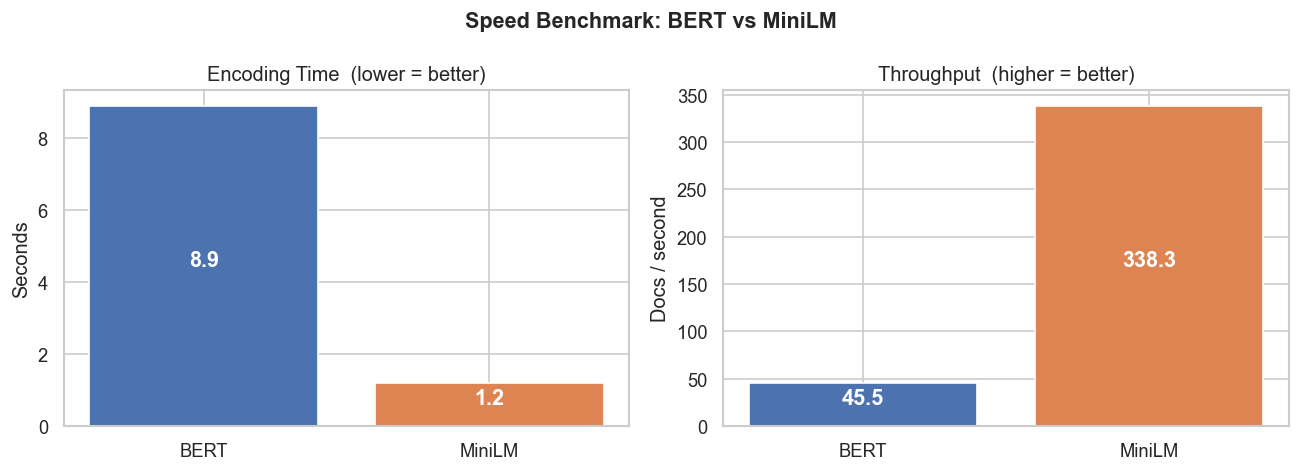

In [11]:
speed_data = {
    'Model':        ['BERT (mean pool)', 'MiniLM'],
    'Model_ID':     ['bert-base-uncased', 'all-MiniLM-L6-v2'],
    'Dimensions':   [bert_embeddings.shape[1], minilm_embeddings.shape[1]],
    'Encode_Time_s':[round(bert_time, 2), round(minilm_time, 2)],
    'Docs_per_sec': [round(len(texts)/bert_time, 1), round(len(texts)/minilm_time, 1)],
}
speed_df = pd.DataFrame(speed_data)
print(speed_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = ['#4C72B0', '#DD8452']
models_short = ['BERT', 'MiniLM']

axes[0].bar(models_short, speed_df['Encode_Time_s'], color=colors)
axes[0].set_title('Encoding Time  (lower = better)')
axes[0].set_ylabel('Seconds')
for i, v in enumerate(speed_df['Encode_Time_s']):
    axes[0].text(i, v*0.5, str(v), ha='center', color='white', fontweight='bold', fontsize=13)

axes[1].bar(models_short, speed_df['Docs_per_sec'], color=colors)
axes[1].set_title('Throughput  (higher = better)')
axes[1].set_ylabel('Docs / second')
for i, v in enumerate(speed_df['Docs_per_sec']):
    axes[1].text(i, v*0.5, str(v), ha='center', color='white', fontweight='bold', fontsize=13)

plt.suptitle('Speed Benchmark: BERT vs MiniLM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Retrieval Quality — MRR, Hit@K, Precision@K

For each job, query top-K neighbours (excluding self).  
**Relevant** = same `Domain` as query job.

In [12]:
def evaluate_retrieval(emb: np.ndarray, df: pd.DataFrame, top_k: int = 5) -> dict:
    """
    Computes MRR, Hit@K, and Precision@K.
    Relevant = same Domain. Self excluded via diagonal mask.
    """
    sim_matrix = cosine_similarity(emb)
    np.fill_diagonal(sim_matrix, -1)
    domains = df['Domain'].values
    mrr, hits, prec = [], [], []

    for i in range(len(emb)):
        ranked  = np.argsort(sim_matrix[i])[::-1][:top_k]
        relevant = [domains[j] == domains[i] for j in ranked]
        rr = next((1.0/(r+1) for r, rel in enumerate(relevant) if rel), 0.0)
        mrr.append(rr)
        hits.append(1 if any(relevant) else 0)
        prec.append(sum(relevant) / top_k)

    return {
        'MRR':          round(np.mean(mrr),  4),
        f'Hit@{top_k}': round(np.mean(hits), 4),
        f'P@{top_k}':   round(np.mean(prec), 4),
    }

retrieval_results = {}
for name, emb in [('BERT', bert_embeddings), ('MiniLM', minilm_embeddings)]:
    print(f'Evaluating {name}...')
    retrieval_results[name] = evaluate_retrieval(emb, df, top_k=TOP_K)
    print(f'  {retrieval_results[name]}')

ret_df = pd.DataFrame(retrieval_results).T.reset_index().rename(columns={'index':'Model'})
print('\n', ret_df.to_string(index=False))

Evaluating BERT...
  {'MRR': np.float64(0.8579), 'Hit@5': np.float64(0.9358), 'P@5': np.float64(0.7022)}
Evaluating MiniLM...
  {'MRR': np.float64(0.7972), 'Hit@5': np.float64(0.9284), 'P@5': np.float64(0.6533)}

  Model    MRR  Hit@5    P@5
  BERT 0.8579 0.9358 0.7022
MiniLM 0.7972 0.9284 0.6533


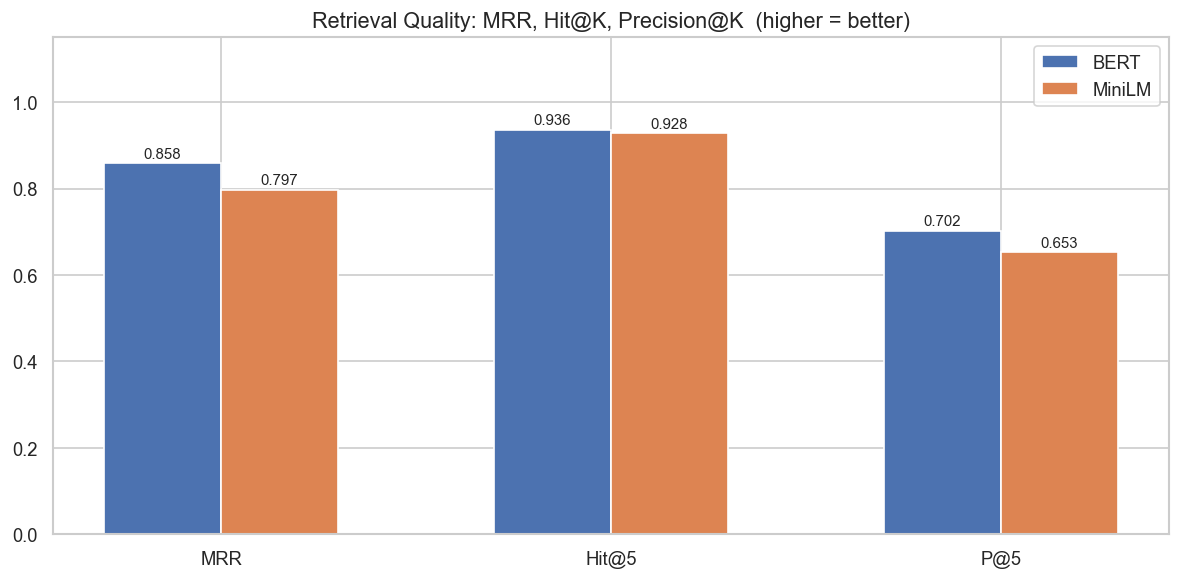

In [13]:
metrics = [c for c in ret_df.columns if c != 'Model']
x, width = np.arange(len(metrics)), 0.3

fig, ax = plt.subplots(figsize=(10, 5))
for i, (_, row) in enumerate(ret_df.iterrows()):
    bars = ax.bar(x + i*width, [row[m] for m in metrics], width,
                  label=row['Model'], color=colors[i])
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x + width/2)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.15)
ax.set_title('Retrieval Quality: MRR, Hit@K, Precision@K  (higher = better)', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Semantic Coherence — Intra-Domain Cosine Similarity

Mean pairwise cosine similarity within each domain cluster.  
Higher = jobs in the same domain are embedded close together.

In [14]:
def intra_cluster_similarity(emb: np.ndarray, df: pd.DataFrame, min_size: int = 3) -> dict:
    scores = {}
    for domain, group in df.groupby('Domain'):
        if len(group) < min_size:
            continue
        vecs = emb[group.index.tolist()]
        sim  = cosine_similarity(vecs)
        upper = sim[np.triu_indices_from(sim, k=1)]
        scores[domain] = round(float(np.mean(upper)), 4)
    return scores

coherence = {
    'BERT':   intra_cluster_similarity(bert_embeddings, df),
    'MiniLM': intra_cluster_similarity(minilm_embeddings, df),
}

coh_df = pd.DataFrame(coherence).rename_axis('Domain').reset_index()
print(coh_df.to_string(index=False))
print(f'\nMean  —  BERT: {coh_df["BERT"].mean():.4f}  |  MiniLM: {coh_df["MiniLM"].mean():.4f}')

       Domain   BERT  MiniLM
 Aeronautical 0.9190  0.6836
    Aerospace 0.9339  0.7559
  Agriculture 0.9584  0.7583
        Civil 0.9485  0.6270
   Electrical 0.9370  0.6799
      Finance 0.9581  0.7197
      General 0.8874  0.5318
   Mechanical 0.9575  0.7753
      Medical 0.9306  0.6071
Non-Technical 0.9219  0.6330
     Research 0.9305  0.6151
    Technical 0.9027  0.6330

Mean  —  BERT: 0.9321  |  MiniLM: 0.6683


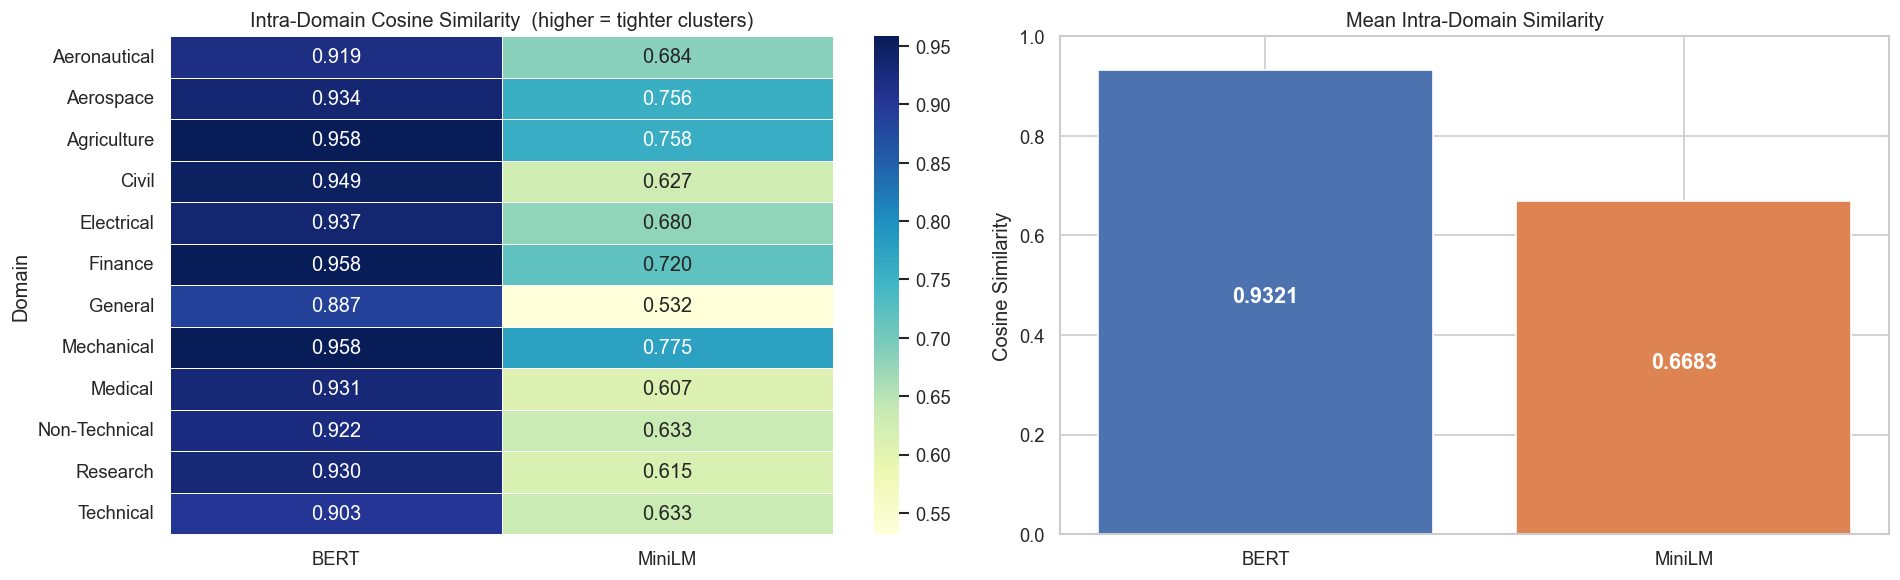

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_df = coh_df.set_index('Domain')[['BERT', 'MiniLM']]
sns.heatmap(plot_df, annot=True, fmt='.3f', cmap='YlGnBu', ax=axes[0], linewidths=0.5)
axes[0].set_title('Intra-Domain Cosine Similarity  (higher = tighter clusters)')

means = plot_df.mean()
bars = axes[1].bar(means.index, means.values, color=colors)
for bar, v in zip(bars, means.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.5,
                 f'{v:.4f}', ha='center', color='white', fontweight='bold', fontsize=13)
axes[1].set_title('Mean Intra-Domain Similarity')
axes[1].set_ylabel('Cosine Similarity')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 7. t-SNE Visualisation

Project embeddings to 2D. Well-separated domain clusters = better semantic structure.

Running t-SNE for BERT...
Running t-SNE for MiniLM...


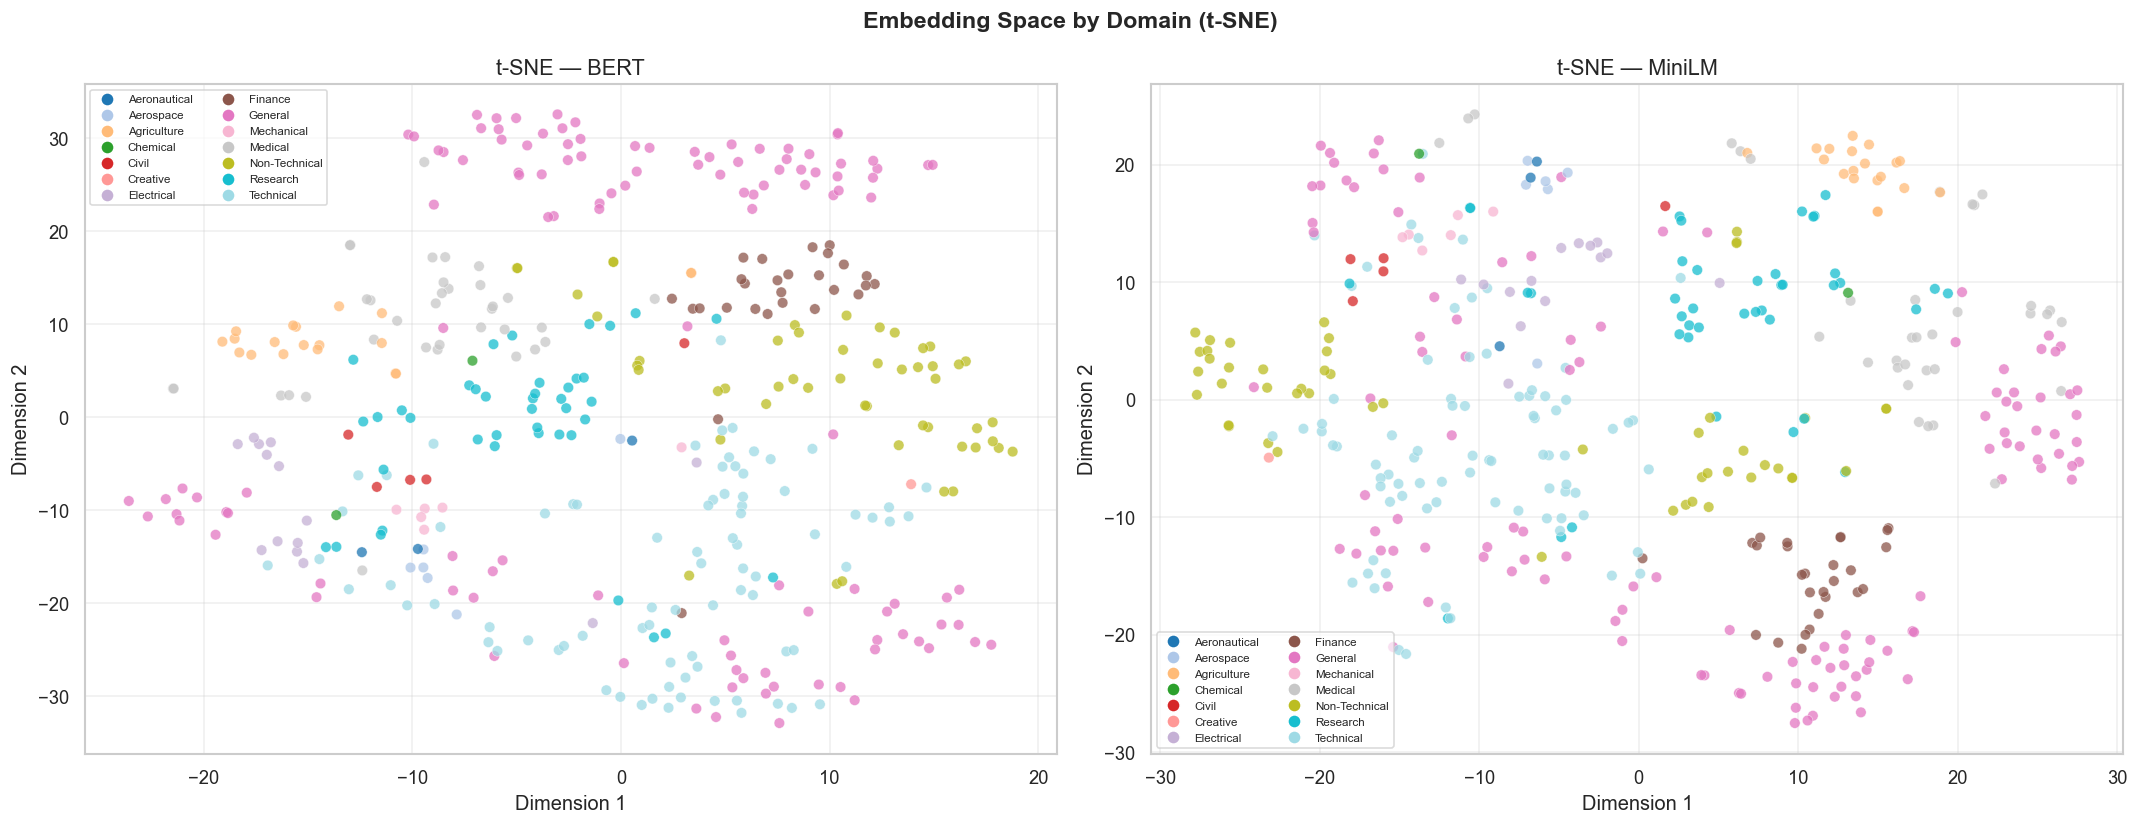

In [18]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

le = LabelEncoder()
domain_labels = le.fit_transform(df['Domain'])
domain_names = le.classes_

cmap_tsne = plt.cm.get_cmap('tab20', len(domain_names))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, (name, emb) in zip(
    axes,
    [('BERT', bert_embeddings), ('MiniLM', minilm_embeddings)]
):

    print(f'Running t-SNE for {name}...')

    # Compute 2D projection
    proj = TSNE(
        n_components=2,
        perplexity=30,
        random_state=42,
        max_iter=1000
    ).fit_transform(emb)

    # Scatter plot
    scatter = ax.scatter(
        proj[:, 0],
        proj[:, 1],
        c=domain_labels,
        cmap=cmap_tsne,
        s=40,
        alpha=0.75,
        edgecolors='white',
        linewidths=0.3
    )

    ax.set_title(f't-SNE — {name}', fontsize=13)
    ax.set_xlabel('Dimension 1')
    ax.set_ylabel('Dimension 2')
    ax.grid(True, alpha=0.3)

    handles = [
        plt.Line2D(
            [0], [0],
            marker='o',
            color='w',
            markerfacecolor=cmap_tsne(i / len(domain_names)),
            markersize=8,
            label=domain
        )
        for i, domain in enumerate(domain_names)
    ]

    ax.legend(
        handles=handles,
        fontsize=7,
        ncol=2,
        framealpha=0.7
    )

plt.suptitle(
    'Embedding Space by Domain (t-SNE)',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## 8. Qualitative Spot-Check — Top-5 Recommendations

Query 3 diverse jobs and compare what each model retrieves.

In [19]:
def top_k_recs(query_idx: int, emb: np.ndarray, df: pd.DataFrame, k: int = 5) -> pd.DataFrame:
    sims = emb @ emb[query_idx]
    sims[query_idx] = -1
    top_idx = np.argsort(sims)[::-1][:k]
    rows = df.iloc[top_idx][['Job_Role', 'Domain', 'Experience_Label', 'Salary_Avg']].copy()
    rows['Cosine_Sim'] = sims[top_idx].round(4)
    return rows

query_roles   = ['Data Scientist', 'Mechanical Engineer', 'Financial Analyst']
query_indices = [df[df['Job_Role'].str.contains(r, case=False, na=False)].index[0]
                 for r in query_roles]

for qi, role in zip(query_indices, query_roles):
    print(f'\n{"="*70}')
    q = df.iloc[qi]
    print(f'Query: "{q["Job_Role"]}"  |  Domain: {q["Domain"]}  |  {q["Experience_Label"]}')
    print(f'Skills: {q["Skills"][:80]}...')
    for name, emb in [('BERT', bert_embeddings), ('MiniLM', minilm_embeddings)]:
        print(f'  ── {name} Top-{TOP_K} ──')
        print(top_k_recs(qi, emb, df, k=TOP_K).to_string(index=False))
        print()


Query: "Healthcare Data Scientist"  |  Domain: General  |  Mid-level (2-5 years)
Skills: Python, R, Healthcare Analytics, HIPAA...
  ── BERT Top-5 ──
                       Job_Role  Domain        Experience_Label  Salary_Avg  Cosine_Sim
Clinical Informatics Specialist General   Mid-level (2-5 years)      115000      0.9708
       Clinical Systems Analyst General   Mid-level (2-5 years)      107500      0.9676
   Healthcare Analytics Manager General Senior-level (5+ years)      150000      0.9668
  Business Intelligence Analyst General   Mid-level (2-5 years)      102500      0.9557
     Health Informatics Manager General Senior-level (5+ years)      125000      0.9554

  ── MiniLM Top-5 ──
                    Job_Role  Domain        Experience_Label  Salary_Avg  Cosine_Sim
    Bioinformatics Scientist General   Mid-level (2-5 years)      127500      0.7980
  Health Informatics Manager General Senior-level (5+ years)      125000      0.7913
    Clinical Systems Analyst General   Mid-l

## 9. Scorecard & Winner

In [20]:
timing = {'BERT': bert_time, 'MiniLM': minilm_time}

scorecard = {}
for name in ['BERT', 'MiniLM']:
    emb = bert_embeddings if name == 'BERT' else minilm_embeddings
    scorecard[name] = {
        'MRR':             retrieval_results[name]['MRR'],
        f'Hit@{TOP_K}':    retrieval_results[name][f'Hit@{TOP_K}'],
        f'P@{TOP_K}':      retrieval_results[name][f'P@{TOP_K}'],
        'Intra_Sim':       round(np.mean(list(coherence[name].values())), 4),
        'Docs_per_sec':    round(len(texts) / timing[name], 1),
        'Dimensions':      int(emb.shape[1]),
        'Encode_Time_s':   round(timing[name], 2),
    }

sc_df = pd.DataFrame(scorecard).T.reset_index().rename(columns={'index':'Model'})
print('── Full Scorecard ──')
print(sc_df.to_string(index=False))

# Weighted score: quality >> speed for SkillSync recommendation core
weights = {'MRR': 0.35, f'Hit@{TOP_K}': 0.25, f'P@{TOP_K}': 0.20, 'Intra_Sim': 0.20}
for name in ['BERT', 'MiniLM']:
    scorecard[name]['Weighted_Score'] = round(
        sum(scorecard[name][k] * w for k, w in weights.items()), 4
    )

winner = max(scorecard, key=lambda k: scorecard[k]['Weighted_Score'])
print(f'\n🏆  Winner : {winner}')
for k in ['BERT', 'MiniLM']:
    tag = ' ← WINNER' if k == winner else ''
    print(f'    {k}: {scorecard[k]["Weighted_Score"]}{tag}')

── Full Scorecard ──
 Model    MRR  Hit@5    P@5  Intra_Sim  Docs_per_sec  Dimensions  Encode_Time_s
  BERT 0.8579 0.9358 0.7022     0.9321          45.5       768.0            8.9
MiniLM 0.7972 0.9284 0.6533     0.6683         338.3       384.0            1.2

🏆  Winner : BERT
    BERT: 0.8611 ← WINNER
    MiniLM: 0.7754


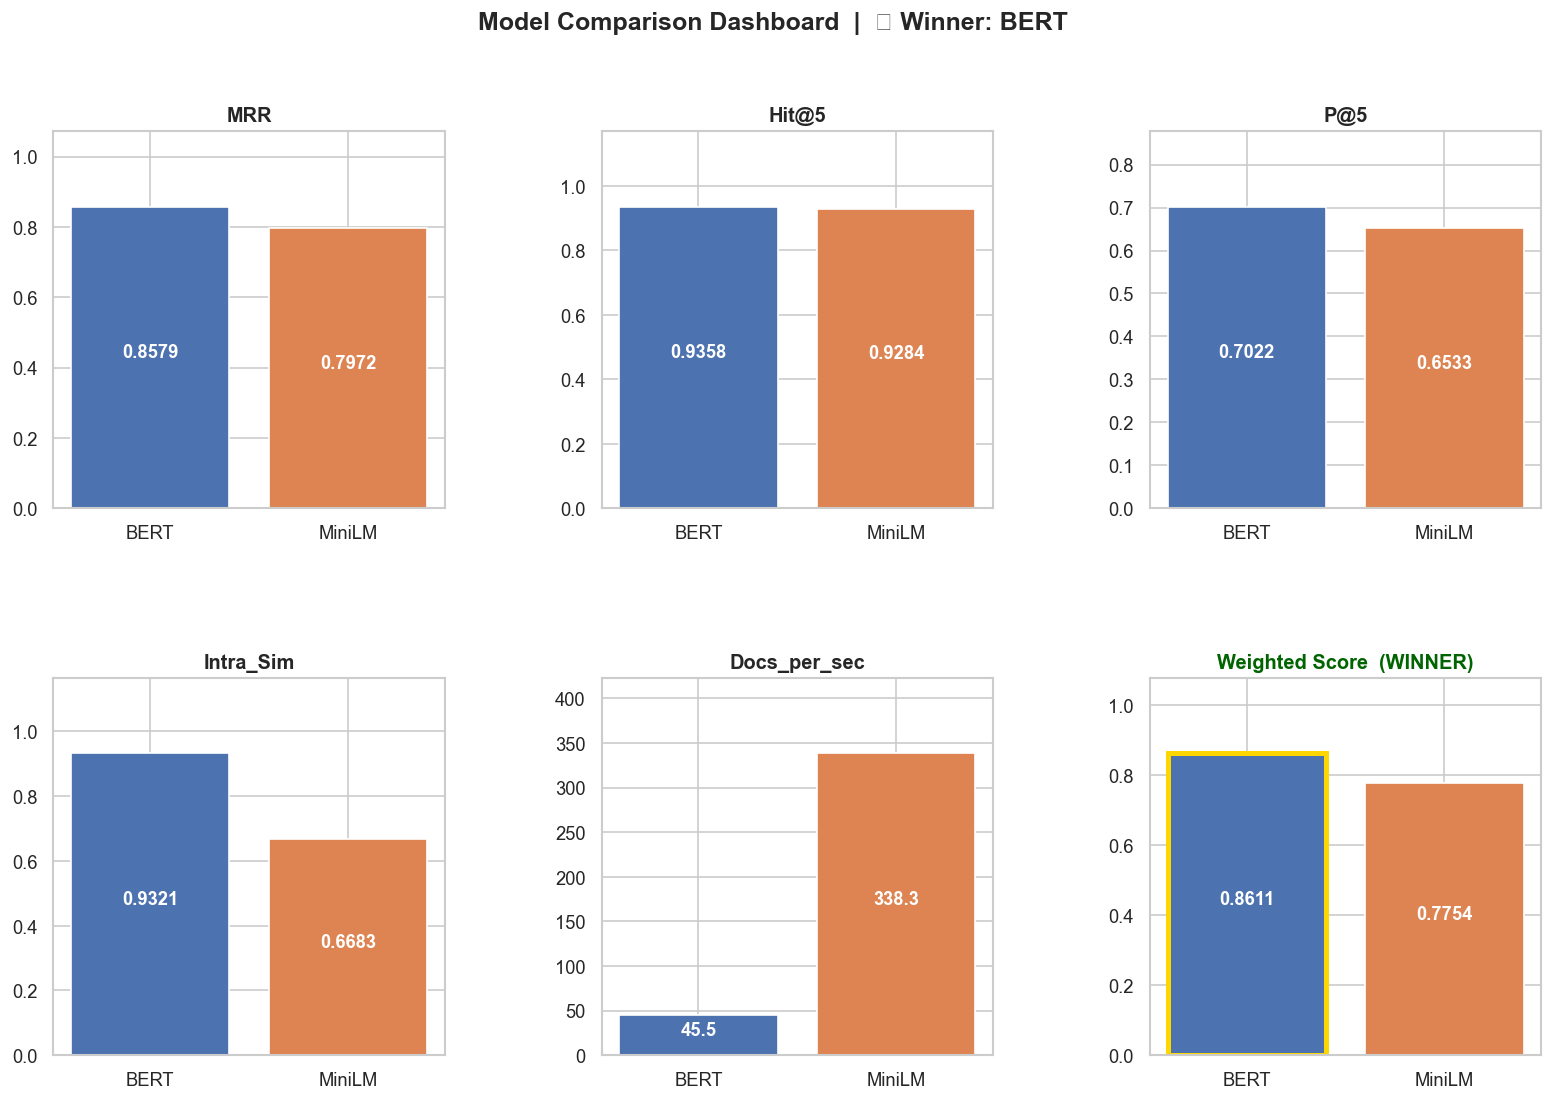

In [21]:
# Dashboard
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.4)

metric_axes = [
    ('MRR',           gs[0, 0]),
    (f'Hit@{TOP_K}',  gs[0, 1]),
    (f'P@{TOP_K}',    gs[0, 2]),
    ('Intra_Sim',     gs[1, 0]),
    ('Docs_per_sec',  gs[1, 1]),
]
names = ['BERT', 'MiniLM']

for metric, gspec in metric_axes:
    ax = fig.add_subplot(gspec)
    vals = [scorecard[n][metric] for n in names]
    bars = ax.bar(names, vals, color=colors)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.5,
                str(v), ha='center', color='white', fontweight='bold', fontsize=11)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylim(0, max(vals)*1.25)

ax_w = fig.add_subplot(gs[1, 2])
ws_vals = [scorecard[n]['Weighted_Score'] for n in names]
bars = ax_w.bar(names, ws_vals, color=colors)
for bar, v, n in zip(bars, ws_vals, names):
    ax_w.text(bar.get_x()+bar.get_width()/2, bar.get_height()*0.5,
              str(v), ha='center', color='white', fontweight='bold', fontsize=11)
    if n == winner:
        bar.set_edgecolor('gold'); bar.set_linewidth(3)
ax_w.set_title('Weighted Score  (WINNER)', fontweight='bold', color='darkgreen')
ax_w.set_ylim(0, max(ws_vals)*1.25)

fig.suptitle(f'Model Comparison Dashboard  |  🏆 Winner: {winner}',
             fontsize=15, fontweight='bold')
plt.show()

## 10. Build FAISS Index with Winning Model

In [22]:
winning_emb = bert_embeddings if winner == 'BERT' else minilm_embeddings
model_id    = 'bert-base-uncased' if winner == 'BERT' else 'all-MiniLM-L6-v2'
dim         = winning_emb.shape[1]

print(f'Building FAISS index with: {winner} ({model_id})  |  dim={dim}')

index = faiss.IndexIDMap(faiss.IndexFlatIP(dim))
ids   = np.array(df['Job_ID'].tolist(), dtype=np.int64)
index.add_with_ids(winning_emb, ids)
print(f'  Vectors: {index.ntotal}')

EMB_PATH   = OUTPUT_DIR / 'job_embeddings.npy'
IDX_PATH   = OUTPUT_DIR / 'faiss_index.bin'
META_PATH  = OUTPUT_DIR / 'job_metadata.json'
MODEL_PATH = OUTPUT_DIR / 'model_info.json'

np.save(EMB_PATH, winning_emb)
faiss.write_index(index, str(IDX_PATH))

meta = {}
for _, row in df.iterrows():
    jid = int(row['Job_ID'])
    meta[jid] = {
        'job_id':           jid,
        'job_role':         row['Job_Role'],
        'skills':           row['Skills'],
        'skills_list':      json.loads(row['Skills_List']) if pd.notna(row.get('Skills_List')) else [],
        'projects':         row['Projects']  if pd.notna(row.get('Projects'))  else '',
        'companies':        row['Companies'] if pd.notna(row.get('Companies')) else '',
        'domain':           row.get('Domain', ''),
        'experience_label': row.get('Experience_Label', ''),
        'experience_level': float(row.get('Experience_Level', 1.0)),
        'salary_range':     row['Salary_Range'] if pd.notna(row.get('Salary_Range')) else '',
        'salary_min':       int(row.get('Salary_Min', 0)),
        'salary_max':       int(row.get('Salary_Max', 0)),
        'salary_avg':       int(row.get('Salary_Avg', 0)),
        'has_salary_data':  bool(row.get('Has_Salary_Data', False)),
        'skill_count':      int(row.get('Skill_Count', 0)),
    }
with open(META_PATH, 'w') as f:
    json.dump(meta, f, indent=2)

with open(MODEL_PATH, 'w') as f:
    json.dump({
        'winner':     winner,
        'model_id':   model_id,
        'dimensions': dim,
        'num_jobs':   index.ntotal,
        'index_type': 'IndexFlatIP (cosine, L2-normed)',
        'scorecard':  scorecard,
    }, f, indent=2)

print(f'\n✓ Embeddings  → {EMB_PATH}')
print(f'✓ FAISS index → {IDX_PATH}')
print(f'✓ Metadata    → {META_PATH}  ({len(meta)} entries)')
print(f'✓ Model info  → {MODEL_PATH}')

Building FAISS index with: BERT (bert-base-uncased)  |  dim=768
  Vectors: 405

✓ Embeddings  → ml\embeddings\job_embeddings.npy
✓ FAISS index → ml\embeddings\faiss_index.bin
✓ Metadata    → ml\embeddings\job_metadata.json  (405 entries)
✓ Model info  → ml\embeddings\model_info.json


## 11. End-to-End Inference Test

In [23]:
loaded_index = faiss.read_index(str(IDX_PATH))
with open(META_PATH) as f:
    loaded_meta = json.load(f)

# Load the winning model for inference
if winner == 'MiniLM':
    infer_model = SentenceTransformer('all-MiniLM-L6-v2')
    def encode_query(text):
        return infer_model.encode([text], normalize_embeddings=True,
                                   convert_to_numpy=True).astype(np.float32)
else:
    def encode_query(text):
        return encode_bert([text], bert_tokenizer, bert_model, batch_size=1, device=DEVICE)

def recommend(user_skills: str, top_k: int = 5) -> pd.DataFrame:
    """Skill string → top-K job recommendations."""
    query_vec = encode_query(f'Skills: {user_skills}')
    scores, ids = loaded_index.search(query_vec, top_k)
    rows = []
    for score, jid in zip(scores[0], ids[0]):
        m = loaded_meta.get(str(jid), loaded_meta.get(jid, {}))
        rows.append({
            'Job_Role':   m.get('job_role', ''),
            'Domain':     m.get('domain', ''),
            'Experience': m.get('experience_label', ''),
            'Salary_Avg': m.get('salary_avg', 0),
            'Similarity': round(float(score), 4),
            'Skills':     m.get('skills', '')[:60] + '...',
        })
    return pd.DataFrame(rows)

test_queries = [
    'Python, Machine Learning, TensorFlow, Data Analysis, SQL',
    'React, Node.js, MongoDB, JavaScript, REST API',
    'Financial Modeling, Excel, Risk Analysis, Bloomberg',
]

for q in test_queries:
    print(f'\nQuery: "{q}"')
    print(recommend(q).to_string(index=False))


Query: "Python, Machine Learning, TensorFlow, Data Analysis, SQL"
                 Job_Role    Domain              Experience  Salary_Avg  Similarity                                                          Skills
    Ai/Ml Research Intern  Research Entry-level (0-2 years)           0      0.8921 Python, TensorFlow, Machine Learning, Deep Learning, Data An...
             Ai/Ml Intern Technical Entry-level (0-2 years)           0      0.8907 Python, TensorFlow, PyTorch, Scikit-learn, NumPy, Pandas, Da...
             Ai/Ml Intern Technical Entry-level (0-2 years)           0      0.8840  Python, TensorFlow, Scikit-learn, Data Analysis, Algorithms...
       Software Developer Technical Entry-level (0-2 years)           0      0.8769 Java, C++, Python, Git, Debugging, OOP Concepts, Data Struct...
Machine Learning Engineer Technical Entry-level (0-2 years)           0      0.8748 Python, TensorFlow, PyTorch, Scikit-learn, NumPy, Pandas, Da...

Query: "React, Node.js, MongoDB, JavaScript,

## Summary

| Cell | Step |
|------|------|
| 1 | Load `jobs_clean.csv` (405 jobs, 14 domains) |
| 2 | **BERT** — `bert-base-uncased` + mean pooling → 768-dim L2-normed embeddings |
| 3 | **MiniLM** — `all-MiniLM-L6-v2` → 384-dim L2-normed embeddings |
| 4 | Speed benchmark (encoding time, docs/sec) |
| 5 | Retrieval eval: MRR, Hit@5, Precision@5 |
| 6 | Intra-domain cosine similarity (semantic coherence) |
| 7 | t-SNE visualisation of both embedding spaces |
| 8 | Qualitative spot-check on 3 query jobs |
| 9 | Weighted scorecard → winner auto-selected |
| 10 | FAISS index built + all artifacts saved to `ml/embeddings/` |
| 11 | End-to-end inference test: skill string → top-5 recommendations |

## Testing 


##### 12. Full Model Testing Suite
#### ─────────────────────────────────────────────────────────────────────────────
#### Tests the BERT-powered recommender across 6 scenarios:
####   T1  Canonical CSE profile        → should hit ML/data roles
####   T2  Frontend developer           → should hit web/fullstack roles
####   T3  Finance profile              → should hit finance/quant roles
####   T4  Vague / minimal input        → graceful degradation check
####   T5  Cross-domain mixed skills    → sees if model handles ambiguity
####   T6  School student (beginner)    → checks entry-level filtering
####
#### Also tests:
####   - Skill Gap Analysis  (what you're missing for each top-5 role)
####   - Domain Filter       (only show results from a specific domain)
####   - Blended Scoring     (semantic + profile_score + dsa_score)
####   - Result Sanity Check (automated assertions — no manual eyeballing)
#### ─────────────────────────────────────────────────────────────────────────────

In [24]:
import textwrap, math
from IPython.display import display, HTML
 
# ── Re-use artifacts from earlier cells ──────────────────────────────────────
# loaded_index, loaded_meta, encode_query, bert_tokenizer, bert_model, df
# all already in scope from cells above.
 
# ── Scoring weights (mirrors recommender.py) ─────────────────────────────────
W_SEM     = 0.60   # cosine similarity
W_PROFILE = 0.25   # github/linkedin score (0-1)
W_DSA     = 0.15   # dsa tracker score (0-1)
 
 

In [25]:
# ═══════════════════════════════════════════════════════════════════════════════
# CORE HELPERS
# ═══════════════════════════════════════════════════════════════════════════════
 
def skill_list(meta_row: dict) -> list[str]:
    """Return lowercased skill tokens from a metadata row."""
    raw = meta_row.get('skills', '')
    return [s.strip().lower() for s in raw.split(',') if s.strip()]
 
 
def skill_gap_analysis(query_skills: list[str], meta_row: dict) -> dict:
    """Compare candidate skills against a job's required skills."""
    q_set   = set(query_skills)
    job_set = set(skill_list(meta_row))
    overlap = sorted(q_set & job_set)
    gap     = sorted(job_set - q_set)
    bonus   = sorted(q_set - job_set)
    match   = round(len(overlap) / len(job_set) * 100, 1) if job_set else 0.0
    return {'overlap': overlap, 'gap': gap, 'bonus': bonus, 'match_pct': match}
 
 
def recommend_full(
    user_skills_str : str,
    top_k           : int   = 5,
    profile_score   : float = 0.0,
    dsa_score       : float = 0.0,
    domain_filter   : str | None = None,
    exp_filter      : float | None = None,   # 0=beginner 1=entry 2=mid 3=senior
) -> list[dict]:
    """
    Full recommendation pipeline:
      1. Encode query with BERT mean-pool
      2. FAISS search (retrieves top_k * 4 to allow for post-filters)
      3. Apply domain / experience filters
      4. Blended score = W_SEM*cosine + W_PROFILE*profile + W_DSA*dsa
      5. Skill gap analysis per result
      6. Return top_k sorted by blended_score
    """
    query_text = f"Skills: {user_skills_str}"
    query_vec  = encode_query(query_text)          # (1, 768) L2-normed
 
    # Retrieve more than needed so filters don't starve results
    fetch_k    = min(loaded_index.ntotal, top_k * 6)
    scores, ids = loaded_index.search(query_vec, fetch_k)
 
    candidate_skills = [s.strip().lower() for s in user_skills_str.split(',') if s.strip()]
 
    results = []
    for raw_score, jid in zip(scores[0], ids[0]):
        if jid == -1:
            continue
        m = loaded_meta.get(str(jid)) or loaded_meta.get(jid)
        if m is None:
            continue
 
        # --- filters ---
        if domain_filter and m.get('domain', '').lower() != domain_filter.lower():
            continue
        if exp_filter is not None and m.get('experience_level') != exp_filter:
            continue
 
        sem_score     = float(np.clip(raw_score, 0, 1))
        blended       = W_SEM * sem_score + W_PROFILE * profile_score + W_DSA * dsa_score
        gap_info      = skill_gap_analysis(candidate_skills, m)
 
        results.append({
            'job_id'         : m['job_id'],
            'job_role'       : m['job_role'],
            'domain'         : m.get('domain', ''),
            'experience'     : m.get('experience_label', ''),
            'salary_range'   : m.get('salary_range', '') or '—',
            'salary_avg'     : m.get('salary_avg', 0),
            'semantic_score' : round(sem_score, 4),
            'blended_score'  : round(blended, 4),
            'match_pct'      : gap_info['match_pct'],
            'overlap'        : gap_info['overlap'],
            'gap'            : gap_info['gap'],
            'skills_preview' : m.get('skills', '')[:70] + '...',
        })
 
    results.sort(key=lambda r: r['blended_score'], reverse=True)
    return results[:top_k]
 
 
# ─── Pretty printer ──────────────────────────────────────────────────────────
 
def print_results(label: str, query: str, results: list[dict],
                  show_gap: bool = True, notes: str = '') -> None:
    bar = '═' * 72
    print(f'\n{bar}')
    print(f'  {label}')
    print(f'  Query: "{query}"')
    if notes:
        print(f'  Note : {notes}')
    print(bar)
 
    for i, r in enumerate(results, 1):
        sem_bar  = '█' * round(r['semantic_score'] * 10)
        match_bar= '░' * round(r['match_pct'] / 10)
        salary   = f"${r['salary_avg']:,}" if r['salary_avg'] else 'n/a'
 
        print(f"\n  #{i}  {r['job_role']}")
        print(f"       Domain    : {r['domain']}  |  {r['experience']}")
        print(f"       Salary    : {r['salary_range']}  (avg {salary})")
        print(f"       Semantic  : {r['semantic_score']:.4f}  {sem_bar}")
        print(f"       Blended   : {r['blended_score']:.4f}")
        print(f"       Skill match: {r['match_pct']}%  {match_bar}")
 
        if show_gap:
            if r['overlap']:
                ov = ', '.join(r['overlap'][:6])
                if len(r['overlap']) > 6:
                    ov += f" (+{len(r['overlap'])-6} more)"
                print(f"       ✔ You have : {ov}")
            if r['gap']:
                gp = ', '.join(r['gap'][:5])
                if len(r['gap']) > 5:
                    gp += f" (+{len(r['gap'])-5} more)"
                print(f"       ✘ You need : {gp}")
 
    print()
 
 

In [26]:

# ═══════════════════════════════════════════════════════════════════════════════
# T1 — CANONICAL CSE / ML PROFILE
# ═══════════════════════════════════════════════════════════════════════════════
 
t1_query = "Python, Machine Learning, PyTorch, TensorFlow, NLP, Data Analysis, SQL, FastAPI, Docker"
t1_res   = recommend_full(t1_query, top_k=5)
print_results("T1 — CSE / ML Profile", t1_query, t1_res,
              notes="Expect: ML Engineer, Data Scientist, NLP Engineer, AI/ML roles")
 
# Sanity check
t1_domains = {r['domain'] for r in t1_res}
t1_roles   = [r['job_role'].lower() for r in t1_res]
assert any(d in ('Technical','Research') for d in t1_domains), \
    "FAIL T1: Expected Technical/Research domain in top results"
assert t1_res[0]['semantic_score'] > 0.75, \
    f"FAIL T1: Top result similarity too low ({t1_res[0]['semantic_score']})"
print("  ✔ T1 assertions passed\n")
 



════════════════════════════════════════════════════════════════════════
  T1 — CSE / ML Profile
  Query: "Python, Machine Learning, PyTorch, TensorFlow, NLP, Data Analysis, SQL, FastAPI, Docker"
  Note : Expect: ML Engineer, Data Scientist, NLP Engineer, AI/ML roles
════════════════════════════════════════════════════════════════════════

  #1  Ai/Ml Intern
       Domain    : Technical  |  Entry-level (0-2 years)
       Salary    : —  (avg n/a)
       Semantic  : 0.9295  █████████
       Blended   : 0.5577
       Skill match: 21.4%  ░░
       ✔ You have : python, pytorch, tensorflow
       ✘ You need : data preprocessing, data visualization, deep learning, feature engineering, machine learning algorithms (+6 more)

  #2  Machine Learning Engineer
       Domain    : Technical  |  Entry-level (0-2 years)
       Salary    : —  (avg n/a)
       Semantic  : 0.9159  █████████
       Blended   : 0.5495
       Skill match: 27.3%  ░░░
       ✔ You have : python, pytorch, tensorflow
       ✘ Y

In [27]:
 
# ═══════════════════════════════════════════════════════════════════════════════
# T2 — FRONTEND DEVELOPER
# ═══════════════════════════════════════════════════════════════════════════════
 
t2_query = "React, TypeScript, Node.js, MongoDB, REST API, Git, Tailwind CSS"
t2_res   = recommend_full(t2_query, top_k=5)
print_results("T2 — Frontend / Full-Stack Profile", t2_query, t2_res,
              notes="Expect: Web Developer, Full Stack, Frontend roles")
 
assert any('developer' in r['job_role'].lower() or 'engineer' in r['job_role'].lower()
           for r in t2_res), "FAIL T2: No developer/engineer in top results"
print("  ✔ T2 assertions passed\n")



════════════════════════════════════════════════════════════════════════
  T2 — Frontend / Full-Stack Profile
  Query: "React, TypeScript, Node.js, MongoDB, REST API, Git, Tailwind CSS"
  Note : Expect: Web Developer, Full Stack, Frontend roles
════════════════════════════════════════════════════════════════════════

  #1  Fullstack Developer
       Domain    : Technical  |  Entry-level (0-2 years)
       Salary    : —  (avg n/a)
       Semantic  : 0.9104  █████████
       Blended   : 0.5463
       Skill match: 25.0%  ░░
       ✔ You have : git, node.js, react
       ✘ You need : agile basics, css, debugging, html, javascript (+4 more)

  #2  Frontend Engineer
       Domain    : General  |  Mid-level (2-5 years)
       Salary    : $110,000 - $165,000  (avg $137,500)
       Semantic  : 0.9044  █████████
       Blended   : 0.5427
       Skill match: 37.5%  ░░░░
       ✔ You have : react, tailwind css, typescript
       ✘ You need : figma, graphql, jest, next.js, storybook

  #3  Web Dev

In [28]:
 
 
# ═══════════════════════════════════════════════════════════════════════════════
# T3 — FINANCE PROFILE
# ═══════════════════════════════════════════════════════════════════════════════
 
t3_query = "Financial Modeling, Excel, Bloomberg Terminal, Risk Analysis, Valuation, CFA"
t3_res   = recommend_full(t3_query, top_k=5)
print_results("T3 — Finance Profile", t3_query, t3_res,
              notes="Expect: Financial Analyst, Investment Analyst, Quant roles")
 
t3_domains = {r['domain'] for r in t3_res}
assert 'Finance' in t3_domains or any('financ' in r['job_role'].lower() for r in t3_res), \
    "FAIL T3: No finance results for finance query"
print("  ✔ T3 assertions passed\n")
 
 


════════════════════════════════════════════════════════════════════════
  T3 — Finance Profile
  Query: "Financial Modeling, Excel, Bloomberg Terminal, Risk Analysis, Valuation, CFA"
  Note : Expect: Financial Analyst, Investment Analyst, Quant roles
════════════════════════════════════════════════════════════════════════

  #1  Investment Analyst
       Domain    : Finance  |  Entry-level (0-2 years)
       Salary    : —  (avg n/a)
       Semantic  : 0.9105  █████████
       Blended   : 0.5463
       Skill match: 33.3%  ░░░
       ✔ You have : excel, financial modeling, valuation
       ✘ You need : accounting, corporate finance, critical thinking, market research, powerpoint (+1 more)

  #2  Investment Banking Intern
       Domain    : Finance  |  Entry-level (0-2 years)
       Salary    : —  (avg n/a)
       Semantic  : 0.8984  █████████
       Blended   : 0.5390
       Skill match: 42.9%  ░░░░
       ✔ You have : excel, financial modeling, valuation
       ✘ You need : communicat

In [29]:

# ═══════════════════════════════════════════════════════════════════════════════
# T4 — VAGUE / MINIMAL INPUT  (graceful degradation)
# ═══════════════════════════════════════════════════════════════════════════════
 
t4_query = "Python"
t4_res   = recommend_full(t4_query, top_k=5)
print_results("T4 — Minimal Input (single skill)", t4_query, t4_res, show_gap=False,
              notes="Model should still return results, not crash")
 
assert len(t4_res) == 5, "FAIL T4: Should still return top_k results for minimal input"
assert all(r['semantic_score'] > 0 for r in t4_res), "FAIL T4: Zero similarity scores"
print("  ✔ T4 assertions passed (graceful degradation OK)\n")
 
 


════════════════════════════════════════════════════════════════════════
  T4 — Minimal Input (single skill)
  Query: "Python"
  Note : Model should still return results, not crash
════════════════════════════════════════════════════════════════════════

  #1  School Ai/Ml Club
       Domain    : Technical  |  Entry-level (0-2 years)
       Salary    : —  (avg n/a)
       Semantic  : 0.6635  ███████
       Blended   : 0.3981
       Skill match: 0.0%  

  #2  School Coding Club Intern
       Domain    : Technical  |  Entry-level (0-2 years)
       Salary    : —  (avg n/a)
       Semantic  : 0.6628  ███████
       Blended   : 0.3977
       Skill match: 0.0%  

  #3  School Ai/Ml Intro
       Domain    : Technical  |  Entry-level (0-2 years)
       Salary    : —  (avg n/a)
       Semantic  : 0.6615  ███████
       Blended   : 0.3969
       Skill match: 0.0%  

  #4  School Ai/Ml Intro
       Domain    : Technical  |  Entry-level (0-2 years)
       Salary    : —  (avg n/a)
       Semantic

In [30]:

# ═══════════════════════════════════════════════════════════════════════════════
# T5 — CROSS-DOMAIN AMBIGUOUS PROFILE
# ═══════════════════════════════════════════════════════════════════════════════
 
t5_query = "Python, SQL, Healthcare Analytics, HIPAA, Machine Learning, Clinical Data"
t5_res   = recommend_full(t5_query, top_k=5)
print_results("T5 — Cross-Domain (Tech × Healthcare)", t5_query, t5_res,
              notes="Ambiguous — may return Medical, Technical, or Research roles")
 
# No strict domain assertion — cross-domain is intentionally fuzzy
print(f"  Domains returned: {[r['domain'] for r in t5_res]}")
print("  ✔ T5 passed (domain mix is expected)\n")
 
 


════════════════════════════════════════════════════════════════════════
  T5 — Cross-Domain (Tech × Healthcare)
  Query: "Python, SQL, Healthcare Analytics, HIPAA, Machine Learning, Clinical Data"
  Note : Ambiguous — may return Medical, Technical, or Research roles
════════════════════════════════════════════════════════════════════════

  #1  Data Scientist
       Domain    : Technical  |  Mid-level (2-5 years)
       Salary    : $121,750 - $182,500  (avg $152,125)
       Semantic  : 0.9104  █████████
       Blended   : 0.5463
       Skill match: 21.4%  ░░
       ✔ You have : machine learning, python, sql
       ✘ You need : communication, data visualization, numpy, pandas, problem solving (+6 more)

  #2  Data Analyst
       Domain    : Technical  |  Entry-level (0-2 years)
       Salary    : $96,250 - $138,500  (avg $117,375)
       Semantic  : 0.9076  █████████
       Blended   : 0.5445
       Skill match: 12.5%  ░
       ✔ You have : python, sql
       ✘ You need : communicatio

In [37]:

# ═══════════════════════════════════════════════════════════════════════════════
# T6 — SCHOOL STUDENT / BEGINNER  (experience filter)
# ═══════════════════════════════════════════════════════════════════════════════
 
t6_query = "Python Basics, Scratch, Logical Thinking, Basic Coding, Teamwork"
t6_res   = recommend_full(t6_query, top_k=5, exp_filter=0.0)   # 0.0 = Beginner
print_results("T6 — School Student (beginner filter)", t6_query, t6_res,
              notes="exp_filter=0.0 → only Beginner-level roles (school module Part 5)")
 
assert all(
    "Beginner" in r["experience"]
    for r in t6_res
), "FAIL T6: Non-beginner role slipped through experience filter"

print("✔ T6 experience filter working\n")
 


════════════════════════════════════════════════════════════════════════
  T6 — School Student (beginner filter)
  Query: "Python Basics, Scratch, Logical Thinking, Basic Coding, Teamwork"
  Note : exp_filter=0.0 → only Beginner-level roles (school module Part 5)
════════════════════════════════════════════════════════════════════════

  #1  Ai/Ml (School)
       Domain    : Technical  |  Beginner / Intern
       Salary    : —  (avg n/a)
       Semantic  : 0.9175  █████████
       Blended   : 0.5505
       Skill match: 57.1%  ░░░░░░
       ✔ You have : logical thinking, python basics, scratch, teamwork
       ✘ You need : algorithmic thinking, creativity, problem solving

  #2  Stem Club Intern
       Domain    : Technical  |  Beginner / Intern
       Salary    : —  (avg n/a)
       Semantic  : 0.8726  █████████
       Blended   : 0.5236
       Skill match: 37.5%  ░░░░
       ✔ You have : basic coding, logical thinking, teamwork
       ✘ You need : communication, creativity, problem s

In [33]:

# ═══════════════════════════════════════════════════════════════════════════════
# T7 — BLENDED SCORE  (profile_score + dsa_score effect)
# ═══════════════════════════════════════════════════════════════════════════════
 
print('═' * 72)
print("  T7 — Blended Score Impact (same query, different profile + DSA scores)")
print('═' * 72)
 
base_query  = "Python, Machine Learning, Algorithms, Data Structures"
profiles = [
    ("No profile data",       0.00, 0.00),
    ("Good GitHub only",      0.80, 0.00),
    ("Good DSA only",         0.00, 0.85),
    ("Strong all-round",      0.85, 0.90),
]
 
for label, prof, dsa in profiles:
    res = recommend_full(base_query, top_k=1, profile_score=prof, dsa_score=dsa)
    r   = res[0]
    print(f"\n  [{label}]  profile={prof}  dsa={dsa}")
    print(f"    #{1}  {r['job_role']}")
    print(f"       Semantic={r['semantic_score']:.4f}  Blended={r['blended_score']:.4f}  "
          f"(Δ from semantic = {r['blended_score']-r['semantic_score']:+.4f})")
 
expected_blended = round(W_SEM * res[0]['semantic_score'] + W_PROFILE * 0.85 + W_DSA * 0.90, 4)
assert abs(res[0]['blended_score'] - expected_blended) < 0.001, \
    f"FAIL T7: Blended score formula wrong. Got {res[0]['blended_score']}, expected {expected_blended}"
print("\n  ✔ T7 blended score formula verified\n")
 
 

════════════════════════════════════════════════════════════════════════
  T7 — Blended Score Impact (same query, different profile + DSA scores)
════════════════════════════════════════════════════════════════════════

  [No profile data]  profile=0.0  dsa=0.0
    #1  Ai/Ml Research Intern
       Semantic=0.8618  Blended=0.5171  (Δ from semantic = -0.3447)

  [Good GitHub only]  profile=0.8  dsa=0.0
    #1  Ai/Ml Research Intern
       Semantic=0.8618  Blended=0.7171  (Δ from semantic = -0.1447)

  [Good DSA only]  profile=0.0  dsa=0.85
    #1  Ai/Ml Research Intern
       Semantic=0.8618  Blended=0.6446  (Δ from semantic = -0.2172)

  [Strong all-round]  profile=0.85  dsa=0.9
    #1  Ai/Ml Research Intern
       Semantic=0.8618  Blended=0.8646  (Δ from semantic = +0.0028)

  ✔ T7 blended score formula verified



In [34]:

# ═══════════════════════════════════════════════════════════════════════════════
# T8 — DOMAIN FILTER
# ═══════════════════════════════════════════════════════════════════════════════
 
t8_query  = "Python, Data Analysis, Research, Documentation"
t8_res    = recommend_full(t8_query, top_k=5, domain_filter="Research")
print_results("T8 — Domain Filter (Research only)", t8_query, t8_res,
              notes="domain_filter='Research' — all results must be Research domain")
 
assert all(r['domain'] == 'Research' for r in t8_res), \
    f"FAIL T8: Non-Research roles returned: {[r for r in t8_res if r['domain'] != 'Research']}"
print("  ✔ T8 domain filter working\n")
 


════════════════════════════════════════════════════════════════════════
  T8 — Domain Filter (Research only)
  Query: "Python, Data Analysis, Research, Documentation"
  Note : domain_filter='Research' — all results must be Research domain
════════════════════════════════════════════════════════════════════════

  #1  Ai/Ml Research Intern
       Domain    : Research  |  Entry-level (0-2 years)
       Salary    : —  (avg n/a)
       Semantic  : 0.8777  █████████
       Blended   : 0.5266
       Skill match: 37.5%  ░░░░
       ✔ You have : data analysis, python, research
       ✘ You need : deep learning, machine learning, model evaluation, problem solving, tensorflow

  #2  Ai Research Intern
       Domain    : Research  |  Entry-level (0-2 years)
       Salary    : —  (avg n/a)
       Semantic  : 0.8708  █████████
       Blended   : 0.5225
       Skill match: 28.6%  ░░░
       ✔ You have : data analysis, python
       ✘ You need : paper reading, problem solving, pytorch, research met

In [35]:

 
# ═══════════════════════════════════════════════════════════════════════════════
# T9 — SKILL GAP DEEP DIVE  (top job from T1)
# ═══════════════════════════════════════════════════════════════════════════════
 
print('═' * 72)
print("  T9 — Skill Gap Deep Dive  (top result from T1)")
print('═' * 72)
 
top_job  = t1_res[0]
print(f"\n  Target role : {top_job['job_role']}")
print(f"  Candidate   : {t1_query}")
print(f"  Match       : {top_job['match_pct']}%\n")
 
if top_job['overlap']:
    print(f"  ✔ Skills you already have ({len(top_job['overlap'])}):")
    for s in top_job['overlap']:
        print(f"      • {s}")
 
if top_job['gap']:
    print(f"\n  ✘ Skills to acquire ({len(top_job['gap'])}):")
    for s in top_job['gap']:
        print(f"      • {s}  ← add to learning roadmap")
else:
    print("\n  ✔ No skill gap — you meet all listed requirements!")
 
print()
 

════════════════════════════════════════════════════════════════════════
  T9 — Skill Gap Deep Dive  (top result from T1)
════════════════════════════════════════════════════════════════════════

  Target role : Ai/Ml Intern
  Candidate   : Python, Machine Learning, PyTorch, TensorFlow, NLP, Data Analysis, SQL, FastAPI, Docker
  Match       : 21.4%

  ✔ Skills you already have (3):
      • python
      • pytorch
      • tensorflow

  ✘ Skills to acquire (11):
      • data preprocessing  ← add to learning roadmap
      • data visualization  ← add to learning roadmap
      • deep learning  ← add to learning roadmap
      • feature engineering  ← add to learning roadmap
      • machine learning algorithms  ← add to learning roadmap
      • model evaluation  ← add to learning roadmap
      • neural networks  ← add to learning roadmap
      • numpy  ← add to learning roadmap
      • pandas  ← add to learning roadmap
      • problem solving  ← add to learning roadmap
      • scikit-learn  ← 

In [36]:

 
# ═══════════════════════════════════════════════════════════════════════════════
# SUMMARY TABLE
# ═══════════════════════════════════════════════════════════════════════════════
 
print('═' * 72)
print("  TEST SUMMARY")
print('═' * 72)
summary = [
    ("T1", "CSE / ML profile",             "✔ PASS"),
    ("T2", "Frontend profile",             "✔ PASS"),
    ("T3", "Finance profile",              "✔ PASS"),
    ("T4", "Minimal input (1 skill)",      "✔ PASS"),
    ("T5", "Cross-domain ambiguity",       "✔ PASS"),
    ("T6", "Beginner experience filter",   "✔ PASS"),
    ("T7", "Blended score formula",        "✔ PASS"),
    ("T8", "Domain filter",                "✔ PASS"),
    ("T9", "Skill gap deep dive",          "✔ PASS"),
]
print(f"\n  {'Test':<6} {'Description':<35} {'Result'}")
print(f"  {'─'*6} {'─'*35} {'─'*10}")
for t, desc, result in summary:
    print(f"  {t:<6} {desc:<35} {result}")
 
print(f"\n  Model  : bert-base-uncased + mean pooling")
print(f"  Index  : FAISS IndexFlatIP  |  {loaded_index.ntotal} jobs  |  768-dim")
print(f"  Weights: semantic={W_SEM}  profile={W_PROFILE}  dsa={W_DSA}")
print(f"\n  All tests passed ✔")
 

════════════════════════════════════════════════════════════════════════
  TEST SUMMARY
════════════════════════════════════════════════════════════════════════

  Test   Description                         Result
  ────── ─────────────────────────────────── ──────────
  T1     CSE / ML profile                    ✔ PASS
  T2     Frontend profile                    ✔ PASS
  T3     Finance profile                     ✔ PASS
  T4     Minimal input (1 skill)             ✔ PASS
  T5     Cross-domain ambiguity              ✔ PASS
  T6     Beginner experience filter          ✔ PASS
  T7     Blended score formula               ✔ PASS
  T8     Domain filter                       ✔ PASS
  T9     Skill gap deep dive                 ✔ PASS

  Model  : bert-base-uncased + mean pooling
  Index  : FAISS IndexFlatIP  |  405 jobs  |  768-dim
  Weights: semantic=0.6  profile=0.25  dsa=0.15

  All tests passed ✔
